# Stage 2 — EVITAS Score (Event Impact & Traffic Assessment Score)

**PRAHARI Layer 1: Event Intelligence**

This notebook computes a single 0–100 EVITAS score per event using:
- `causal_delta` — counterfactual impact from the DR Learner (Stage 1)
- `severity_score` — engineered 0–3 ordinal from priority + road closure
- `closure_rate` — corridor's historical closure tendency
- `time_of_day_factor` — peak-hour multiplier

**Colour thresholds:** 🟢 Green (0–39) · 🟡 Yellow (40–59) · 🟠 Orange (60–79) · 🔴 Red (80–100)

**Input:** raw ASTraM CSV  
**Outputs:** `evitas_scores.csv`, `corridor_evitas_summary.csv`

In [1]:
# ── CELL 1 ── Imports
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from lightgbm import LGBMClassifier, LGBMRegressor

try:
    from econml.dr import DRLearner
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'econml', '-q'])
    from econml.dr import DRLearner

print('All imports OK')

All imports OK


In [3]:
# ── CELL 2 ── Load Data
# ► Colab: uncomment the block below
# from google.colab import files
# import io
# uploaded = files.upload()
# df = pd.read_csv(io.BytesIO(list(uploaded.values())[0]))

# ► Local: set the path directly
# Upload Dataset (Local System)

import pandas as pd

DATA_PATH = r"C:/Users/shrav/OneDrive/Desktop/Prototype/files/Astram event data_anonymized - Astram event data_anonymizedb40ac87 (1).csv"  # Change to your file location

df = pd.read_csv(DATA_PATH)

print(f'Loaded {len(df):,} rows · {df.columns.size} columns')

print("Data loaded successfully! Here are the first 5 rows:")
display(df.head())

Loaded 8,173 rows · 46 columns
Data loaded successfully! Here are the first 5 rows:


,id,event_type,latitude,longitude,endlatitude,endlongitude,address,end_address,event_cause,requires_road_closure,...,resolved_at_address,resolved_at_latitude,resolved_at_longitude,closed_by_id,closed_datetime,resolved_by_id,resolved_datetime,gba_identifier,zone,junction
0,FKID000000,unplanned,13.040004,77.518099,0.000000,0.000000,"Mumbai Bengaluru Highway, Jalahalli Cross Junc...",NaN,vehicle_breakdown,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,FKID000001,unplanned,12.921876,77.645158,0.000000,0.000000,"19th Main Road, Heavie Halcyon, Agara, HSR Lay...",NaN,vehicle_breakdown,False,...,"19th Main Road, Heavie Halcyon, Agara, HSR Lay...",12.921876,77.645158,NaN,NaN,FKUSR00002,2024-01-30 04:17:46.828355+00,NaN,NaN,NaN
2,FKID000002,unplanned,12.955622,77.585708,0.000000,0.000000,"Lalbagh Main Road, Dr Sri Shantaveera Swami Ci...",NaN,others,False,...,NaN,NaN,NaN,FKUSR00003,2024-01-30 04:56:03.281509+00,NaN,NaN,Bengaluru Central Corporation,Central Zone 2,UrvashiJunction
3,FKID000003,unplanned,13.006147,77.579435,13.006239,77.579516,"Sankey Road, Bashyam Circle, Sadashiva Nagar, ...","Sankey Road, Palace Orchard Upper, Sadashiva N...",tree_fall,True,...,NaN,NaN,NaN,FKUSR00004,2024-03-14 07:42:05.54944+00,NaN,NaN,NaN,NaN,NaN
4,FKID000004,unplanned,12.953980,77.585233,0.000000,0.000000,"Lalbagh Fort Road, Lalbagh Main Gate Junction,...",NaN,vehicle_breakdown,False,...,NaN,NaN,NaN,FKUSR00003,2024-01-30 05:35:17.338283+00,NaN,NaN,NaN,NaN,LalbaghMainGateJunc


In [4]:
# ── CELL 3 ── Replicate Stage-1 Feature Engineering
# (must be identical to Stage 1 so models & encoders stay consistent)

# Priority → numeric
df['priority_num'] = df['priority'].map({'High': 2, 'Low': 1}).fillna(1).astype(int)
df['closure_num']  = df['requires_road_closure'].astype(int)
df['severity_score'] = df['closure_num'] * 2 + (df['priority_num'] - 1)

# Temporal
df['start_dt']   = pd.to_datetime(df['start_datetime'], utc=True, errors='coerce')
df['hour']        = df['start_dt'].dt.hour.fillna(12).astype(int)
df['day_of_week'] = df['start_dt'].dt.dayofweek.fillna(0).astype(int)
df['month']       = df['start_dt'].dt.month.fillna(1).astype(int)
df['is_weekend']  = (df['day_of_week'] >= 5).astype(int)
df['is_peak_hour'] = df['hour'].isin([7, 8, 9, 17, 18, 19, 20]).astype(int)

# Spatial label encoding
label_encoders = {}
for col in ['corridor', 'zone', 'police_station']:
    le = LabelEncoder()
    df[col + '_enc'] = le.fit_transform(df[col].fillna('Unknown'))
    label_encoders[col] = le

df['corridor_name'] = df['corridor'].fillna('Unknown')
df['zone_name']     = df['zone'].fillna('Unknown')
df['latitude']  = df['latitude'].fillna(df['latitude'].median())
df['longitude'] = df['longitude'].fillna(df['longitude'].median())

df = df.dropna(subset=['hour']).reset_index(drop=True)

FEATURE_COLS = [
    'hour', 'day_of_week', 'month', 'is_weekend', 'is_peak_hour',
    'corridor_enc', 'zone_enc', 'police_station_enc',
    'latitude', 'longitude',
]
X = df[FEATURE_COLS].values
Y = df['severity_score'].values.astype(float)

# Treatment: planned = 1, unplanned = 0
df['W'] = (df['event_type'] == 'planned').astype(int)
W = df['W'].values

print(f'Features: {X.shape}  |  Y range: {Y.min()}–{Y.max()}  |  Planned events: {W.sum()}')

Features: (8173, 10)  |  Y range: 0.0–3.0  |  Planned events: 467


In [5]:
# ── CELL 4 ── Fit DR Learner (same as Stage 1)
propensity_model = LGBMClassifier(
    n_estimators=200, learning_rate=0.05, max_depth=4,
    num_leaves=15, random_state=42, verbose=-1,
)
outcome_model = LGBMRegressor(
    n_estimators=200, learning_rate=0.05, max_depth=4,
    num_leaves=15, random_state=42, verbose=-1,
)
dr = DRLearner(
    model_propensity=propensity_model,
    model_regression=outcome_model,
    model_final=LGBMRegressor(n_estimators=100, max_depth=3, verbose=-1),
    cv=3, random_state=42,
)
print('Fitting DR Learner (~30–60 s) ...')
dr.fit(Y, W, X=X)
df['cate'] = dr.effect(X)

# Simple outcome model for counterfactual absolutes
outcome_simple = LGBMRegressor(n_estimators=300, max_depth=5, verbose=-1)
outcome_simple.fit(np.column_stack([X, W]), Y)

df['pred_severity_if_planned']   = outcome_simple.predict(np.column_stack([X, np.ones(len(X))]))
df['pred_severity_if_unplanned'] = outcome_simple.predict(np.column_stack([X, np.zeros(len(X))]))
df['causal_delta'] = df['pred_severity_if_planned'] - df['pred_severity_if_unplanned']

print(f'Global ATE: {df["cate"].mean():.4f}  |  Causal delta mean: {df["causal_delta"].mean():.4f}')

Fitting DR Learner (~30–60 s) ...
Global ATE: 0.5230  |  Causal delta mean: 0.5196


In [6]:
# ── CELL 5 ── Build Corridor Closure Rate (needed for EVITAS)
corridor_closure = (
    df.groupby('corridor_name')['closure_num']
    .mean()
    .rename('corridor_closure_rate')
)
df = df.join(corridor_closure, on='corridor_name')
print('Corridor closure rates computed')

Corridor closure rates computed


In [7]:
# ── CELL 6 ── EVITAS Score Formula
#
# Raw EVITAS = 0.35 * norm(causal_delta)
#            + 0.30 * norm(severity_score)
#            + 0.20 * norm(corridor_closure_rate)
#            + 0.15 * time_of_day_factor          ← peak/off-peak modifier
#
# Each component is min–max normalised to [0, 1].
# Final score = raw_evitas * 100, clipped to [0, 100].

def minmax_norm(series: pd.Series) -> pd.Series:
    lo, hi = series.min(), series.max()
    return (series - lo) / (hi - lo + 1e-9)

# Time-of-day factor:
#   Peak hours (7-9 AM, 5-8 PM) → 1.0
#   Shoulder hours (6 AM, 10 AM, 4 PM, 9 PM) → 0.6
#   Off-peak → 0.3
PEAK_HOURS    = {7, 8, 9, 17, 18, 19, 20}
SHOULDER_HOURS = {6, 10, 16, 21}

def time_factor(hour: int) -> float:
    if hour in PEAK_HOURS:
        return 1.0
    elif hour in SHOULDER_HOURS:
        return 0.6
    return 0.3

df['time_of_day_factor'] = df['hour'].apply(time_factor)

# Compute normalised components
df['norm_causal_delta']   = minmax_norm(df['causal_delta'])
df['norm_severity']       = minmax_norm(df['severity_score'].astype(float))
df['norm_closure_rate']   = minmax_norm(df['corridor_closure_rate'].fillna(0))

# Weighted sum → 0–100
df['evitas_raw'] = (
    0.35 * df['norm_causal_delta']
  + 0.30 * df['norm_severity']
  + 0.20 * df['norm_closure_rate']
  + 0.15 * df['time_of_day_factor']
)

df['evitas_score'] = (df['evitas_raw'] * 100).clip(0, 100).round(1)

# Colour-coded risk band
def evitas_band(score: float) -> str:
    if score >= 80:
        return 'RED'
    elif score >= 60:
        return 'ORANGE'
    elif score >= 40:
        return 'YELLOW'
    return 'GREEN'

df['evitas_band'] = df['evitas_score'].apply(evitas_band)

print('EVITAS score distribution:')
print(df['evitas_band'].value_counts())
print(f'\nMean EVITAS: {df["evitas_score"].mean():.1f}  |  Max: {df["evitas_score"].max():.1f}')

EVITAS score distribution:
evitas_band
YELLOW    5213
GREEN     2138
ORANGE     799
RED         23
Name: count, dtype: int64

Mean EVITAS: 46.7  |  Max: 91.0


In [8]:
# ── CELL 7 ── Export per-event EVITAS table
OUTPUT_COLS = [
    'id', 'event_type', 'event_cause', 'start_datetime',
    'corridor_name', 'zone_name', 'latitude', 'longitude',
    'priority', 'requires_road_closure',
    'severity_score', 'cate', 'causal_delta',
    'corridor_closure_rate', 'hour', 'time_of_day_factor',
    'norm_causal_delta', 'norm_severity', 'norm_closure_rate',
    'evitas_score', 'evitas_band',
]

evitas_df = df[OUTPUT_COLS].copy().sort_values('evitas_score', ascending=False)
evitas_df.to_csv('evitas_scores.csv', index=False)
print(f'Saved evitas_scores.csv  ({len(evitas_df):,} rows)')

print('\nTop 15 highest EVITAS events:')
display(evitas_df[[
    'event_cause', 'corridor_name', 'zone_name',
    'severity_score', 'causal_delta', 'evitas_score', 'evitas_band'
]].head(15))

Saved evitas_scores.csv  (8,173 rows)

Top 15 highest EVITAS events:


,event_cause,corridor_name,zone_name,severity_score,causal_delta,evitas_score,evitas_band
7226,vehicle_breakdown,Mysore Road,Central Zone 2,3,1.202797,91.0,RED
2075,accident,Mysore Road,Unknown,3,1.247419,85.7,RED
7650,construction,Mysore Road,Central Zone 2,3,1.452002,84.5,RED
2008,vip_movement,Mysore Road,Unknown,3,1.421846,84.1,RED
2015,vip_movement,Mysore Road,Unknown,3,1.421846,84.1,RED
2057,vip_movement,Mysore Road,Unknown,3,1.421846,84.1,RED
1970,vip_movement,Mysore Road,Unknown,3,1.421846,84.1,RED
820,water_logging,Varthur Road,Unknown,3,0.660947,83.3,RED
6309,vehicle_breakdown,Mysore Road,Central Zone 2,3,1.356172,83.0,RED
7546,vehicle_breakdown,Non-corridor,East Zone 2,2,1.168500,82.2,RED


In [9]:
# ── CELL 8 ── Corridor-level EVITAS Summary (input for Stage 3)
corridor_evitas = df.groupby('corridor_name').agg(
    event_count          = ('id', 'count'),
    mean_evitas          = ('evitas_score', 'mean'),
    max_evitas           = ('evitas_score', 'max'),
    red_events           = ('evitas_band', lambda x: (x == 'RED').sum()),
    orange_events        = ('evitas_band', lambda x: (x == 'ORANGE').sum()),
    mean_causal_delta    = ('causal_delta', 'mean'),
    closure_rate         = ('closure_num', 'mean'),
    mean_severity        = ('severity_score', 'mean'),
    planned_rate         = ('W', 'mean'),
    zone                 = ('zone_name', lambda x: x.mode()[0]),
    lat                  = ('latitude', 'mean'),
    lon                  = ('longitude', 'mean'),
).reset_index()

corridor_evitas['risk_rank'] = corridor_evitas['mean_evitas'].rank(ascending=False).astype(int)
corridor_evitas = corridor_evitas.sort_values('mean_evitas', ascending=False)

corridor_evitas.to_csv('corridor_evitas_summary.csv', index=False)
print(f'Saved corridor_evitas_summary.csv  ({len(corridor_evitas)} corridors)')

display(corridor_evitas[[
    'corridor_name', 'zone', 'event_count',
    'mean_evitas', 'max_evitas', 'red_events', 'orange_events',
    'mean_causal_delta', 'closure_rate', 'risk_rank'
]])

Saved corridor_evitas_summary.csv  (23 corridors)


,corridor_name,zone,event_count,mean_evitas,max_evitas,red_events,orange_events,mean_causal_delta,closure_rate,risk_rank
21,Varthur Road,East Zone 1,77,61.514286,83.3,1,39,0.760995,0.116883,1
10,Mysore Road,Unknown,743,56.976447,91.0,15,245,0.600491,0.110363,2
4,CBD 1,Unknown,26,53.365385,70.2,0,3,0.392129,0.115385,3
14,ORR North 1,Unknown,275,52.433455,79.7,0,27,0.659091,0.080000,4
0,Airport New South Road,North Zone 1,67,51.019403,73.5,0,8,0.261004,0.104478,5
17,Old Airport Road,Unknown,76,50.705263,73.9,0,6,0.637161,0.078947,6
22,West of Chord Road,Unknown,174,50.152874,76.5,0,11,0.709897,0.063218,7
12,ORR East 1,Unknown,244,49.891803,79.5,0,23,0.530678,0.073770,8
18,Old Madras Road,Unknown,263,49.377186,74.9,0,12,0.858003,0.045627,9
11,Non-corridor,Unknown,3124,47.730634,82.2,7,359,0.533713,0.120999,10


In [10]:
# ── CELL 9 ── predict_evitas() — what-if query function

def predict_evitas(
    corridor: str,
    hour: int,
    day_of_week: int,
    month: int,
    lat: float,
    lon: float,
    priority: str = 'High',
    requires_road_closure: bool = False,
    is_planned: bool = True,
) -> dict:
    """
    Compute EVITAS score for a hypothetical future event.

    Parameters
    ----------
    corridor              : corridor name (must match a known label)
    hour                  : 0–23
    day_of_week           : 0=Mon … 6=Sun
    month                 : 1–12
    lat, lon              : event coordinates
    priority              : 'High' or 'Low'
    requires_road_closure : True / False
    is_planned            : True / False

    Returns
    -------
    dict with evitas_score, evitas_band, causal_delta, severity_score,
         component breakdown, and a plain-English recommendation.
    """
    corridor_enc = (
        label_encoders['corridor'].transform([corridor])[0]
        if corridor in label_encoders['corridor'].classes_
        else 0
    )

    is_weekend  = int(day_of_week >= 5)
    is_peak     = int(hour in PEAK_HOURS)

    x_row = np.array([[
        hour, day_of_week, month, is_weekend, is_peak,
        corridor_enc, 0, 0, lat, lon,
    ]])

    w_val = 1 if is_planned else 0
    sev_planned   = float(outcome_simple.predict(np.column_stack([x_row, [[1]]  ]))[0])
    sev_unplanned = float(outcome_simple.predict(np.column_stack([x_row, [[0]]  ]))[0])
    causal_delta  = sev_planned - sev_unplanned

    prio_num     = 2 if priority == 'High' else 1
    closure_num  = int(requires_road_closure)
    sev_score    = float(closure_num * 2 + (prio_num - 1))

    # Corridor closure rate from historical data
    corr_closure = df[df['corridor_name'] == corridor]['corridor_closure_rate'].mean()
    corr_closure = corr_closure if not np.isnan(corr_closure) else 0.0

    tod_factor = time_factor(hour)

    # Normalise using training-set ranges
    def safe_norm(val, col):
        lo, hi = df[col].min(), df[col].max()
        return float(np.clip((val - lo) / (hi - lo + 1e-9), 0, 1))

    n_delta   = safe_norm(causal_delta,  'causal_delta')
    n_sev     = safe_norm(sev_score,     'severity_score')
    n_closure = safe_norm(corr_closure,  'corridor_closure_rate')

    evitas_raw   = 0.35 * n_delta + 0.30 * n_sev + 0.20 * n_closure + 0.15 * tod_factor
    evitas_score = float(np.clip(evitas_raw * 100, 0, 100))
    band         = evitas_band(evitas_score)

    # Recommendation
    rec_map = {
        'RED':    f'⛔  CRITICAL — Pre-deploy 3+ officers to {corridor} T-60 min. Activate diversion.',
        'ORANGE': f'🟠  HIGH     — Pre-deploy 2 officers to {corridor} T-45 min. Alert control room.',
        'YELLOW': f'🟡  MEDIUM   — Alert nearest zone officer. Monitor {corridor}.',
        'GREEN':  f'🟢  LOW      — Standard monitoring. No pre-deployment needed.',
    }

    return {
        'evitas_score'   : round(evitas_score, 1),
        'evitas_band'    : band,
        'causal_delta'   : round(causal_delta, 4),
        'severity_score' : sev_score,
        'corridor_closure_rate': round(corr_closure, 4),
        'time_of_day_factor'   : tod_factor,
        'components'     : {
            'causal_delta_contribution'  : round(0.35 * n_delta * 100, 1),
            'severity_contribution'      : round(0.30 * n_sev   * 100, 1),
            'closure_rate_contribution'  : round(0.20 * n_closure * 100, 1),
            'time_factor_contribution'   : round(0.15 * tod_factor * 100, 1),
        },
        'recommendation' : rec_map[band],
    }

# ── Demo query ──
result = predict_evitas(
    corridor='Tumkur Road',
    hour=8,
    day_of_week=0,   # Monday
    month=3,
    lat=13.04,
    lon=77.52,
    priority='High',
    requires_road_closure=True,
    is_planned=True,
)

print('── EVITAS Demo Output ──')
for k, v in result.items():
    print(f'  {k}: {v}')

── EVITAS Demo Output ──
  evitas_score: 69.0
  evitas_band: ORANGE
  causal_delta: 0.7026
  severity_score: 3.0
  corridor_closure_rate: 0.0262
  time_of_day_factor: 1.0
  components: {'causal_delta_contribution': 19.7, 'severity_contribution': 30.0, 'closure_rate_contribution': 4.3, 'time_factor_contribution': 15.0}
  recommendation: 🟠  HIGH     — Pre-deploy 2 officers to Tumkur Road T-45 min. Alert control room.


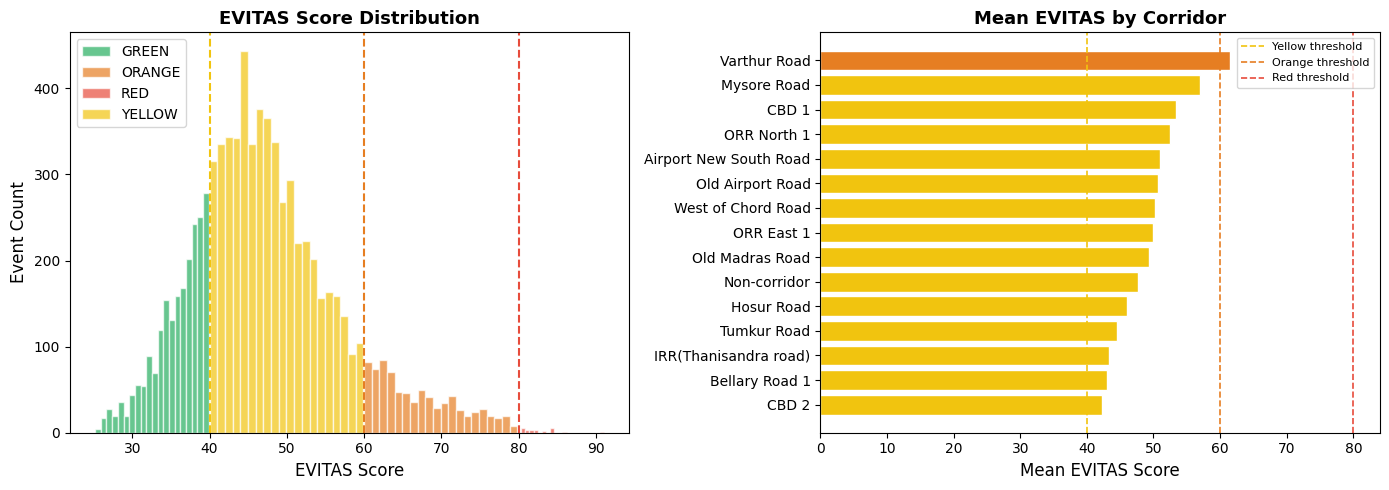

Saved evitas_distribution.png


In [11]:
# ── CELL 10 ── Visual: EVITAS Score Distribution
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: score histogram with band shading
ax = axes[0]
colors_map = {'GREEN': '#27ae60', 'YELLOW': '#f1c40f', 'ORANGE': '#e67e22', 'RED': '#e74c3c'}
band_order = ['GREEN', 'YELLOW', 'ORANGE', 'RED']

for band_name, grp in df.groupby('evitas_band'):
    ax.hist(grp['evitas_score'], bins=20, alpha=0.7,
            color=colors_map[band_name], label=band_name, edgecolor='white')

for thresh, color in [(40, '#f1c40f'), (60, '#e67e22'), (80, '#e74c3c')]:
    ax.axvline(thresh, color=color, linestyle='--', linewidth=1.5)

ax.set_xlabel('EVITAS Score', fontsize=12)
ax.set_ylabel('Event Count', fontsize=12)
ax.set_title('EVITAS Score Distribution', fontsize=13, fontweight='bold')
ax.legend()

# Right: mean EVITAS by corridor (bar chart)
ax2 = axes[1]
top = corridor_evitas.sort_values('mean_evitas', ascending=True).tail(15)
bar_colors = [colors_map[evitas_band(s)] for s in top['mean_evitas']]
bars = ax2.barh(top['corridor_name'], top['mean_evitas'], color=bar_colors, edgecolor='white')
ax2.axvline(40, color='#f1c40f', linestyle='--', linewidth=1.2, label='Yellow threshold')
ax2.axvline(60, color='#e67e22', linestyle='--', linewidth=1.2, label='Orange threshold')
ax2.axvline(80, color='#e74c3c', linestyle='--', linewidth=1.2, label='Red threshold')
ax2.set_xlabel('Mean EVITAS Score', fontsize=12)
ax2.set_title('Mean EVITAS by Corridor', fontsize=13, fontweight='bold')
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig('evitas_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved evitas_distribution.png')

## Outputs produced

| File | Contents |
|---|---|
| `evitas_scores.csv` | Per-event EVITAS scores + band + all components |
| `corridor_evitas_summary.csv` | Per-corridor aggregated EVITAS — **input for Stage 3** |
| `evitas_distribution.png` | Visual overview of score distribution |

## EVITAS Formula (reference)

```
EVITAS = 100 × (
    0.35 × norm(causal_delta)          ← DR Learner counterfactual impact
  + 0.30 × norm(severity_score)        ← priority + road closure (0–3)
  + 0.20 × norm(corridor_closure_rate) ← historical corridor closure rate
  + 0.15 × time_of_day_factor          ← peak=1.0, shoulder=0.6, off-peak=0.3
)
```

## Colour Thresholds
| Score | Band | Action |
|---|---|---|
| 0–39 | 🟢 GREEN | Standard monitoring |
| 40–59 | 🟡 YELLOW | Alert nearest zone officer |
| 60–79 | 🟠 ORANGE | Pre-deploy 2 officers, T-45 min |
| 80–100 | 🔴 RED | Pre-deploy 3+ officers + activate diversion |

→ **Next: Stage 3 — ILP Manpower Optimizer** uses `corridor_evitas_summary.csv` as input.